In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.special import betaln
import pandas as pd
from scipy.special import logsumexp
from mpl_toolkits.mplot3d import Axes3D

# Lecture 10

## Full Bayesian Model for the Kidney Cancer Dataset

We have been discussing the following dataset for the past few lectures (this data is from Section 2.7 of the book "Bayesian Data Analysis Edition 3" by Gelman et al). Some of the code is taken from a blog post by Robin Ryder (google this).

In [56]:
#Read the kidney cancer dataset
d_full = pd.read_csv("KidneyCancerClean.csv", skiprows=4)
d = d_full[['state', 'Location', 'fips', 'dc', 'pop', 'dc.2', 'pop.2']].copy()
d['dct'] = d['dc'] + d['dc.2'] #dct stands for death count total
d['popm'] = (d['pop'] + d['pop.2']) / 2
display(d.head(15))

,state,Location,fips,dc,pop,dc.2,pop.2,dct,popm
0,ALABAMA,"Autauga County, Alabama",1001,2,61921,1,64915,3,63418.0
1,ALABAMA,"Baldwin County, Alabama",1003,7,170945,15,195253,22,183099.0
2,ALABAMA,"Barbour County, Alabama",1005,0,33316,1,33987,1,33651.5
3,ALABAMA,"Bibb County, Alabama",1007,0,30152,1,31175,1,30663.5
4,ALABAMA,"Blount County, Alabama",1009,3,88342,5,91547,8,89944.5
5,ALABAMA,"Bullock County, Alabama",1011,0,8313,0,8197,0,8255.0
6,ALABAMA,"Butler County, Alabama",1013,0,31963,1,31722,1,31842.5
7,ALABAMA,"Calhoun County, Alabama",1015,9,243105,12,233021,21,238063.0
8,ALABAMA,"Chambers County, Alabama",1017,7,59985,0,57813,7,58899.0
9,ALABAMA,"Cherokee County, Alabama",1019,0,43401,0,43828,0,43614.5


We use the following model for this data. Below $i$ represents each individual county, $X_i$ is the death count due to kidney cancer in county $i$ in the period 1980-89, and $n_i$ is a measure of the average population for county $i$ in the same time period. The data on $X_1, \dots, X_N$ are in the column **dct** and the data on $n_1, \dots, n_N$ are in the column **popm**.
\begin{align*}
   &\log a, \log b \overset{\text{i.i.d}}{\sim} \text{uniform}(-\infty, \infty) \\
   & \theta_i \mid a, b \overset{\text{i.i.d}}{\sim} Beta(a, b) \\
   & X_i \mid \theta_i \overset{\text{independent}}{\sim} Bin(n_i, \theta_i). 
\end{align*}
The unknown parameters in this model are $a, b, \theta_1, \dots, \theta_N$. Note that we are using uninformative priors on $a$ and $b$. In  other words, we are not including any information (such as kidney cancer deaths are rare so $a$ must be much smaller compared to $b$) in the model.  

The posterior is the distribution of $a, b, \theta_1, \dots, \theta_N$ conditional on the data $X_1, \dots, X_N$ (note that $n_i$s are being treated as fixed known constants). We can break the posterior as: 
\begin{align*}
   f_{a, b, \theta_1, \dots, \theta_N \mid \text{data}}(a, b, \theta_1, \dots, \theta_n) &= f_{a, b \mid \text{data}}(a, b) \times f_{\theta_1, \dots, \theta_N \mid \text{data}, a, b}(\theta_1, \dots, \theta_N) \\
   &= f_{a, b \mid \text{data}}(a, b) \times \prod_{i=1}^N f_{\theta_i \mid \text{data}, a, b}(\theta_i). 
\end{align*}
It is easy to see that, conditional on $a$ and $b$, the posterior of $\theta_i$ is in closed form and given by the $Beta(X_i + a, n_i - X_i + b)$ distribution. Further the posterior of $a$ and $b$ is given by: 
\begin{align*}
   f_{a, b \mid \text{data}}(a, b) & \propto f_{a, b}(a, b) \times f_{\text{data} \mid a, b}(data) \\
   &= \frac{I\{a > 0, b > 0\}}{a b} \prod_{i=1}^N \int f_{X_i \mid a, b, \theta_i}(X_i) f_{\theta_i \mid a, b}(\theta_i) d\theta_i \\ & = \frac{I\{a > 0, b > 0\}}{a b} \times \prod_{i=1}^N {n_i \choose X_i} \frac{B(X_i + a, n_i-X_i + b)}{B(a, b)} \propto \frac{I\{a > 0, b > 0\}}{a b} \prod_{i=1}^N \frac{B(X_i + a, n_i-X_i + b)}{B(a, b)} 
\end{align*}
This posterior density of $a, b$ is in closed form (even though it is not a standard density) so it can be evaluated numerically on a grid of values of $a, b$. Specifically, we compute the unnormalized posterior for each point $(a, b)$ in the same grid that we previously used for marginal maximum likelihood in the last lecture. After that, we normalize it by dividing each weight by the sum of the unnormalized posterior weights. This gives a discrete approximation for the posterior of $a$ and $b$, which we can use for computing the posterior means, obtaining posterior samples of $a, b$ etc. 

In [57]:
#same grids that we used for the marginal MLE estimation:
loga_low = np.log(1)
loga_high = np.log(100)
#loga_low = -20.0
#loga_high = 20.0

logb_low = np.log(50000)
logb_high = np.log(300000)

gridres = 500

a_grid = np.exp(np.linspace(loga_low, loga_high, gridres))
b_grid = np.exp(np.linspace(logb_low, logb_high, gridres))

x = d['dct'].to_numpy()
n = d['popm'].to_numpy()
nmx = n-x
N = len(x)

log_post_ab = np.empty((len(a_grid), len(b_grid)))
log_b = np.log(b_grid)

for i, a in enumerate(a_grid):
    ll = np.sum(betaln(x[:, None] + a, nmx[:, None] + b_grid[None, :]),axis=0) - N * betaln(a, b_grid)  
    log_post_ab[i, :] = ll -  np.log(a) - log_b #log of the unnormalized posterior

post_ab = np.exp(log_post_ab - logsumexp(log_post_ab))

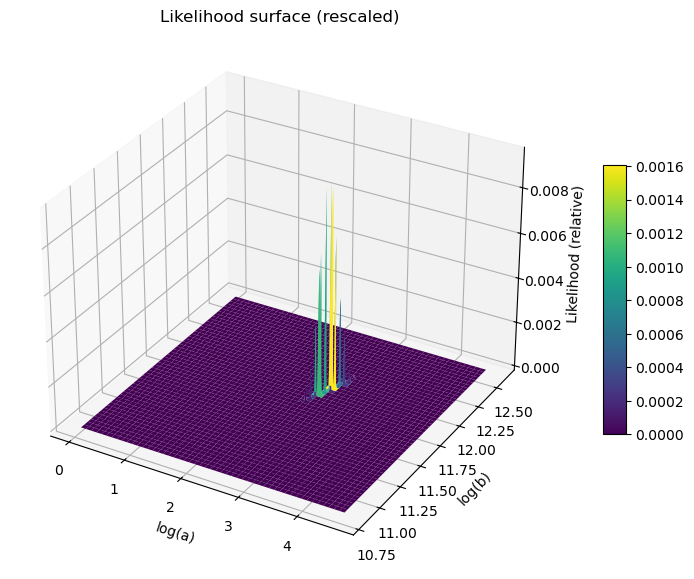

In [58]:

A, B = np.meshgrid(np.log(a_grid), np.log(b_grid), indexing="ij")

fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    A, B, post_ab,
    cmap="viridis",
    linewidth=0,
    antialiased=True
)

ax.set_xlabel("log(a)")
ax.set_ylabel("log(b)")
ax.set_zlabel("Likelihood (relative)")
ax.set_title("Likelihood surface (rescaled)")

fig.colorbar(surf, shrink=0.5, aspect=12)

plt.show()


This plot shows that the posterior for $a, b$ is highly peaked. For better visualization, we can only plot for values closer to the peak. 

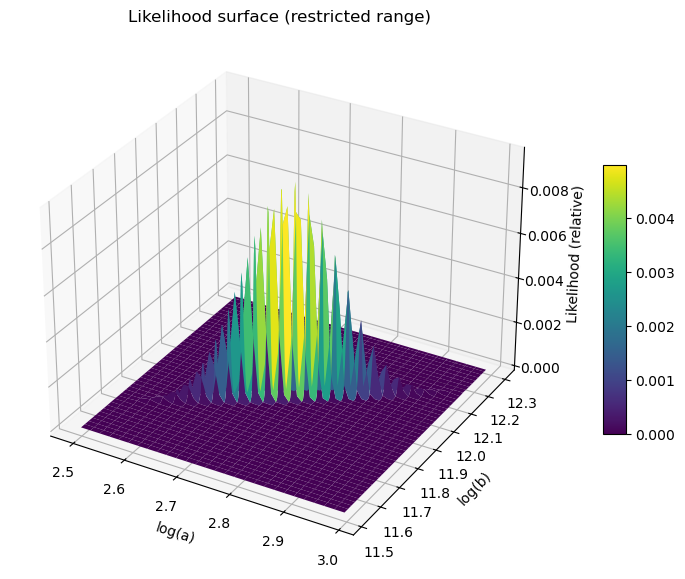

In [59]:
a_mask = (a_grid >= 12) & (a_grid <= 20)
b_mask = (b_grid >= 100_000) & (b_grid <= 220_000)
a_sub = a_grid[a_mask]
b_sub = b_grid[b_mask]
post_sub = post_ab[np.ix_(a_mask, b_mask)]
A, B = np.meshgrid(np.log(a_sub), np.log(b_sub), indexing="ij")
fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    A, B, post_sub,
    cmap="viridis",
    linewidth=0,
    antialiased=True
)

ax.set_xlabel("log(a)")
ax.set_ylabel("log(b)")
ax.set_zlabel("Likelihood (relative)")
ax.set_title("Likelihood surface (restricted range)")

fig.colorbar(surf, shrink=0.5, aspect=12)
plt.show()



From the discretized posterior approximation, we can compute the posterior means of $a$, $b$, and also draw posterior samples from $a$ and $b$.

In [60]:
a_postmean = np.sum(a_grid[:, None] * post_ab)
b_postmean = np.sum(b_grid[None, :] * post_ab)
print(f"Estimated a (post mean): {a_postmean}, Estimated b (post mean): {b_postmean}")

Estimated a (post mean): 15.602962147435006, Estimated b (post mean): 150546.7012850137


Below we draw posterior samples of $a$ and $b$. 

15.608661834843717 150602.65073293887


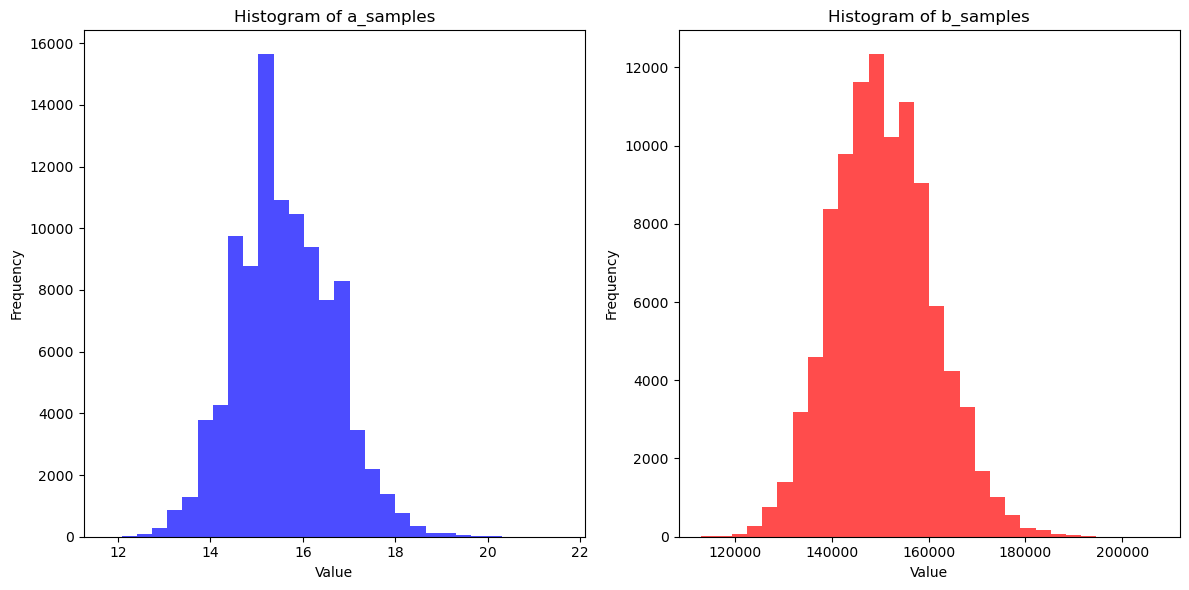

In [61]:
M = 100000  # number of samples

Na, Nb = post_ab.shape

# flatten posterior
p = post_ab.ravel()  # shape (Na * Nb,)

# sample indices
idx = np.random.choice(Na * Nb, size=M, replace=True, p=p)

# convert flat indices back to (i, j)
i_samples, j_samples = np.unravel_index(idx, (Na, Nb))

# map to parameter values
a_samples = a_grid[i_samples]
b_samples = b_grid[j_samples]
print(np.mean(a_samples), np.mean(b_samples))

#plotting the histograms of a_samples and b_samples
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

axes[0].hist(a_samples, bins=30, color='blue', alpha=0.7, label='a_samples')
axes[0].set_title('Histogram of a_samples')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')

axes[1].hist(b_samples, bins=30, color='red', alpha=0.7, label='b_samples')
axes[1].set_title('Histogram of b_samples')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


What about the posterior for $\theta_1, \dots, \theta_N$? Because: 
\begin{align*}
  f_{\theta_1, \dots, \theta_N \mid \text{data}}(\theta_1, \dots, \theta_N) & \propto \int f_{\theta_1, \dots, \theta_N \mid \text{data}, a, b}(\theta_1, \dots, \theta_N) f_{a, b \mid \text{data}}(a, b) da db \\
&= \int \left[\prod_{i=1}^N f_{\theta_i \mid \text{data}, a, b}(\theta_i)\right] f_{a, b \mid \text{data}}(a, b) da db \\
&= \int \left[\prod_{i=1}^N f_{Beta(X_i + a, n_i - X_i + b)}(\theta_i)\right] f_{a, b \mid \text{data}}(a, b) da db,
\end{align*}
it is natural to generate samples from $\theta_1, \dots, \theta_N$ as follows: 
1. Generate posterior samples $a^{(j)}$ and $b^{(j)}$ from $a, b$. 
2. For each $a^{(j)}$ and $b^{(j)}$, generate  $\theta_i^{(j)} \sim Beta(X_i + a^{(j)}, n_i - X_i + b^{(j)})$ for $i = 1, \dots, N$. 
This is illustrated below. 

In [62]:
alpha = x[None, :] + a_samples[:, None]     #shape is (M, N)
beta  = nmx[None, :] + b_samples[:, None]    #shape is (M, N)

theta_samples = np.random.beta(alpha, beta).astype(np.float32) #shape is (M, N)

state                      NEBRASKA
Location    Arthur County, Nebraska
fips                          31005
dc                                0
pop                            1295
dc.2                              0
pop.2                          1172
dct                               0
popm                         1233.5
Name: 1624, dtype: object
0.00010284908


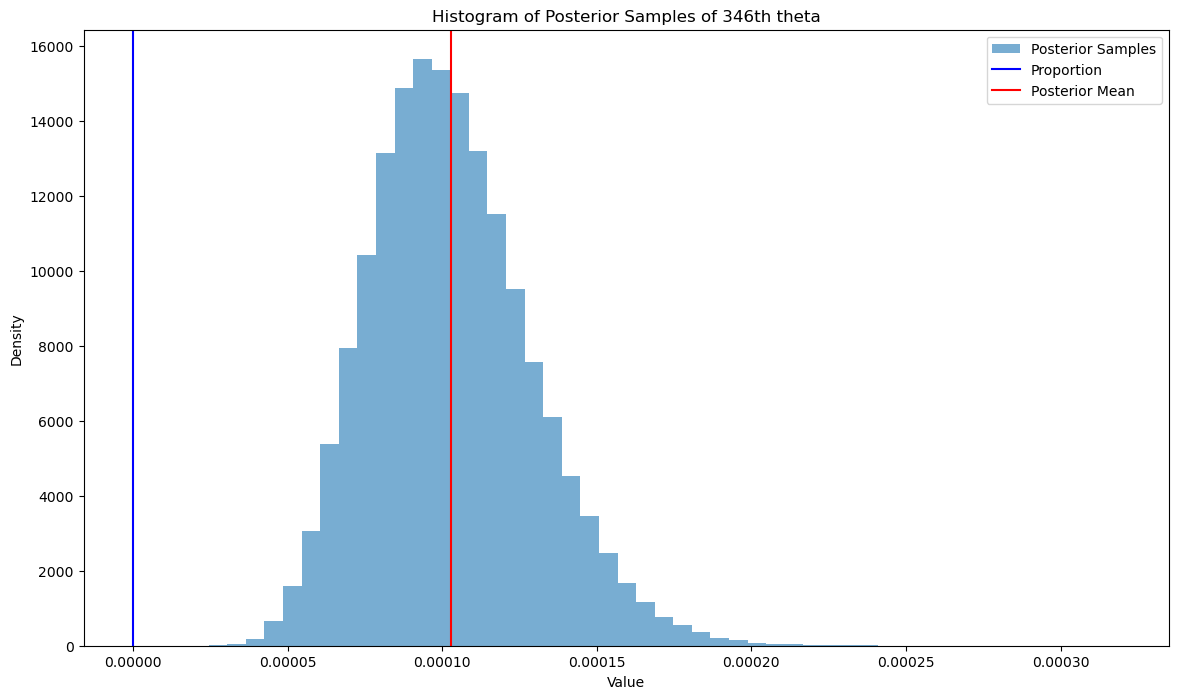

In [64]:
#Let us investigate the theta samples:
#As before, we can look at the histogram of the posterior samples for theta_346 and
#compare it with the Beta posterior from the previous analysis
key_ind = 1624
print(d.iloc[key_ind])
theta_key_ind_samples = theta_samples[:, key_ind]
print(np.mean(theta_key_ind_samples))

# Plotting histogram
plt.figure(figsize = (14, 8))
plt.hist(theta_key_ind_samples, bins=50, density=True, alpha=0.6, label="Posterior Samples")

Tot = round(d.loc[key_ind, 'popm'])
Pos = d.loc[key_ind, 'dct']

plt.axvline(x = Pos/Tot, color = 'blue', label = 'Proportion') #line at the naive proportion
plt.axvline(x = np.mean(theta_key_ind_samples), color = 'red',  label = 'Posterior Mean') #line at the posterior mean

# Labels, legend, and title
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend(loc="upper right")
plt.title("Histogram of Posterior Samples of 346th theta")
plt.show()

Suppose for this county, we want to predict the number of deaths (due to kidney cancer) in the next 10 year period: $X_i^{\text{next}}$, assuming that the average population over the next 10 year period is $n_i^{\text{next}}$. We can answer this by calculating the conditional distribution: 
\begin{align*}
   X_i^{\text{next}} \mid \text{data}, n_i^{\text{next}}. 
\end{align*}
Write
\begin{align*}
    \mathbb{P} \left\{X_i^{\text{next}} = x\mid \text{data}, n_i^{\text{next}} \right\} &= \int_0^1 \mathbb{P}\left\{X_i^{\text{next}} = x \mid \theta_i, \text{data}, n_i^{\text{next}}\right\} f_{\theta_i \mid \text{data}, n_i^{\text{next}}}(\theta_i) d\theta_i \\
    &= \int_0^1 \mathbb{P}\left\{X_i^{\text{next}} = x \mid \theta_i, n_i^{\text{next}}\right\} f_{\theta_i \mid \text{data}}(\theta_i) d\theta_i \\
    &= \int_0^1 \mathbb{P} \left\{Bin(n_i^{\text{next}}, \theta_i) = x \right\} f_{\theta_i \mid \text{data}}(\theta_i) d\theta_i
\end{align*}
By simulation, this can be done in the following way. For each posterior sample of $\theta_i$, we just simulate $X_i^{\text{next}}$ using the Binomial distribution with $n_i^{\text{next}}$ and $\theta_i$. 

In [ ]:
n_next = n.astype(int) #I am assuming that n_{next} = n, i.e. the population size in the next year is the same as the current year. If the actual future population size is available, we can use it
X_next_samples = np.random.binomial(n=n_next[None, :], p=theta_samples)  # shape (M, N)

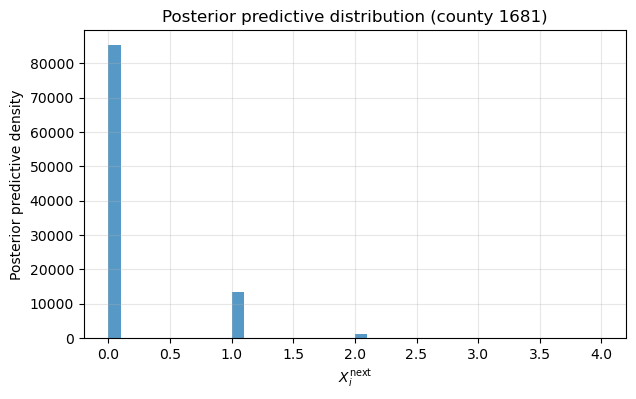

In [ ]:
#key_ind = 346
#key_ind = 1624
key_ind = 1681
x_next_i = X_next_samples[:, key_ind]   # shape (M,)
plt.figure(figsize=(7, 4))
plt.hist(x_next_i, bins=40, density=False, alpha=0.75)
plt.xlabel(r"$X_i^{\mathrm{next}}$")
plt.ylabel("Posterior predictive density")
plt.title(f"Posterior predictive distribution (county {key_ind})")
plt.grid(alpha=0.3)
plt.show()


## Connection to the James-Stein Estimator 

The above analysis is closely connected to the classical James-Stein estimator in the context of normal likelihoods. We shall look at this connection next. It is standard to use the following dataset (from Chapter 1 in Bradley Efron's book on Large Scale Inference) to demonstrate the good performance of the James-Stein Estimator compared to the naive estimator. It corresponds to baseball batting averages for 18 players from the 1970 baseball season. From the data on the number of hits for each player in their first 45 at bats, the goal is to predict their end of season batting averages. The end of season batting averages are also provided in the dataset, but we will only use them to verify the accuracy of estimators.

In [70]:
baseball = pd.DataFrame({
    "players": [
        "Clemente", "F Robinson", "F Howard", "Johnstone", "Berry",
        "Spencer", "Kessinger", "L Alvarado", "Santo", "Swoboda",
        "Unser", "Williams", "Scott", "Petrocelli", "E Rodriguez",
        "Campaneris", "Munson", "Alvis"
    ],
    "hits": [
        18, 17, 16, 15, 14, 14, 13, 12, 11,
        11, 10, 10, 10, 10, 10, 9, 8, 7
    ],
    "atbats": [45] * 18,
    "EoSaverage": [
        0.346, 0.298, 0.276, 0.222, 0.273, 0.270, 0.263, 0.210,
        0.269, 0.230, 0.264, 0.256, 0.303, 0.264, 0.226,
        0.286, 0.316, 0.200
    ]
})
print(baseball)


        players  hits  atbats  EoSaverage
0      Clemente    18      45       0.346
1    F Robinson    17      45       0.298
2      F Howard    16      45       0.276
3     Johnstone    15      45       0.222
4         Berry    14      45       0.273
5       Spencer    14      45       0.270
6     Kessinger    13      45       0.263
7    L Alvarado    12      45       0.210
8         Santo    11      45       0.269
9       Swoboda    11      45       0.230
10        Unser    10      45       0.264
11     Williams    10      45       0.256
12        Scott    10      45       0.303
13   Petrocelli    10      45       0.264
14  E Rodriguez    10      45       0.226
15   Campaneris     9      45       0.286
16       Munson     8      45       0.316
17        Alvis     7      45       0.200


It is natural here to use the model $X_i \sim Bin(n, p_i)$ where $p_i$ denotes the end of season average (estimation target) of player $i$, $X_i$ is the number of hits for player $i$ in their first $n = 45$ at bats. As in the kidney cancer dataset, we can model $p_i \sim Beta(a, b)$ with a further uninformative prior for $a$ and $b$. This will be done in a homework problem. 

To bring about the connection to the James-Stein estimator, we shall work with the normal likelihood (as opposed to Binomial likelihood) in this problem. Specifically, we assume that
\begin{align*}
   \frac{X_i}{n} \overset{\text{ind}}{\sim} N\left(p_i, \frac{p_i(1-p_i)}{n} \right) ~\text{ for $i = 1, \dots, N$}
\end{align*}
This can be justified by the normal approximation (Central Limit Theorem) applied to $Bin(n, p_i)$. Here $N = 18$ denotes the number of players.  

An annoying feature of this normal likelihood is that the variance depends on the unknown $p_i$ and it also varies with $i$. Efron deals with this by simply replacing $p_i$ by the quantity $N^{-1}\sum_{i=1}^N (X_i/n)$ computed from the data, and then treating it as fixed. A more principled way of dealing with this is to use the Variance Stabilizing Transformation for the Binomial (see e.g., \url{https://en.wikipedia.org/wiki/Variance-stabilizing_transformation}). This uses the fact that: 
\begin{align*}
    g(X_i/n) \overset{\text{approx}}{\sim} N(g(p_i), 1) ~~ \text{ for $g(x) := 2 \sqrt{n} \arcsin(\sqrt{x})$}. 
\end{align*}
This is easy to see: one simply writes $g(X_i/n) \approx g(p_i) + g'(p_i) (X_i/n - p_i)$, the right side is a linear function of $X_i/n$ so its distribution can be computed explicitly using $X_i/n \sim N(p_i, p_i(1-p_i)/n)$. 

Writing $Y_i = g(X_i/n)$ and $\theta_i = g(p_i)$, the problem can be reformulated as that of estimating $\theta_1, \dots \theta_N$ from $Y_1, \dots Y_N$ with $Y_i \overset{\text{ind}}{\sim} N(\theta_i, 1)$. Below we compute $Y_i$ and the true values $\theta_i$ which are the target of estimation. 

In [ ]:
# Apply the transformation: 2 * sqrt(n) * arcsin(sqrt(p))
n = 45
baseball["norm_data"] = 2 * np.sqrt(n) * np.arcsin(np.sqrt(baseball["hits"] / n))
baseball["true_mean"] = 2 * np.sqrt(n) * np.arcsin(np.sqrt(baseball["EoSaverage"]))
print(baseball)


        players  hits  atbats  EoSaverage  norm_data  true_mean
0      Clemente    18      45       0.346   9.186472   8.436950
1    F Robinson    17      45       0.298   8.880653   7.747378
2      F Howard    16      45       0.276   8.571275   7.421080
3     Johnstone    15      45       0.222   8.257527   6.582296
4         Berry    14      45       0.273   7.938497   7.375984
5       Spencer    14      45       0.270   7.938497   7.330733
6     Kessinger    13      45       0.263   7.613147   7.224523
7    L Alvarado    12      45       0.210   7.280268   6.386664
8         Santo    11      45       0.269   6.938425   7.315614
9       Swoboda    11      45       0.230   6.938425   6.710614
10        Unser    10      45       0.264   6.585882   7.239751
11     Williams    10      45       0.256   6.585882   7.117400
12        Scott    10      45       0.303   6.585882   7.820536
13   Petrocelli    10      45       0.264   6.585882   7.239751
14  E Rodriguez    10      45       0.22

The naive estimator for $\theta_i$ is simply $Y_i$. The James-Stein estimator is given by: 
\begin{align*}
   \hat{\theta}^{JS}_i = \bar{Y}_N + \left(1 - \frac{N-3}{\sum_{i=1}^N(Y_i - \bar{Y}_N)} \right) \left(Y_i - \bar{Y}_N \right)
\end{align*}
where $\bar{Y}_N := (Y_1 + \dots + Y_N)/N$ is the mean of the observations $Y_i$. 

Below we compute the James-Stein estimator and compare the squared errors for both the James-Stein and the naive estimator. We are able to compute these squared errors because the ground truth $\theta_i$ values are known. 

In [ ]:
# Mean of normalized data
mu = baseball["norm_data"].mean()
# James–Stein estimator
fctr = 1 - (len(baseball["norm_data"]) - 3) / np.sum((baseball["norm_data"] - mu) ** 2)
baseball["js"] = mu + (baseball["norm_data"] - mu) * fctr
# Compare squared errors in transformed space
print(np.sum((baseball["norm_data"] - baseball["true_mean"]) ** 2), np.sum((baseball["js"] - baseball["true_mean"]) ** 2))

17.610557418678166 5.015274172196248


It is easy to see that the James-Stein estimator is better by more than a factor of $3$ compared to the naive estimator. We can convert back to the original scale $p_i$ (by applying the inverse transformation of $g$), and check prediction accuracy on the original scale. 

Convert to original scale. 

In [74]:
baseball["orig_js"] = np.sin(baseball["js"] / (2 * np.sqrt(n))) ** 2
print(np.sum((baseball["hits"] / n - baseball["EoSaverage"]) ** 2), np.sum((baseball["orig_js"] - baseball["EoSaverage"]) ** 2))
print(np.sum(np.abs(baseball["hits"] / n - baseball["EoSaverage"])),np.sum(np.abs(baseball["orig_js"] - baseball["EoSaverage"])))

0.07548795061728396 0.02158970459666336
0.996 0.47556635567349737


Here also the James-Stein estimator is much better than the naive estimator.

In the next lecture, we shall see the connection between the James-Stein estimator and Bayesian inference in this setting. 